In [1]:
import sys
import os
proj_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

In [2]:
from weather_mind.utils import (
    estimate_average_bottom_bar_height,
    remove_bottom_bar_from_folder,
)

In [3]:
from pathlib import Path

INPUT_DIR = Path("../data/7410")

avg_h = estimate_average_bottom_bar_height(
    folder=INPUT_DIR,
    sample_count=20,
    seed=42,
    ignore_zero=True,
    verbose=True,
)
print(f"\nEstimated average bottom-bar height: {avg_h} px")

[bar-height] snap_7410_20241128_142639_28d2459e.jpg: 50px
[bar-height] snap_7410_20250323_171823_be119689.jpg: 50px
[bar-height] snap_7410_20250224_062432_5011d76a.jpg: 50px
[bar-height] snap_7410_20250322_182121_985599f4.jpg: 50px
[bar-height] snap_7410_20250103_071750_2adb395e.jpg: 50px
[bar-height] snap_7410_20241107_054934_e71f81fd.jpg: 50px
[bar-height] snap_7410_20250306_224747_c82227c3.jpg: 50px
[bar-height] snap_7410_20250301_181844_46d16996.jpg: 50px
[bar-height] snap_7410_20250209_200752_398b9056.jpg: 50px
[bar-height] snap_7410_20250705_052638_4ef65c2e.jpg: 50px
[bar-height] snap_7410_20250510_044049_7928b71c.jpg: 50px
[bar-height] snap_7410_20250714_112958_71b9d279.jpg: 50px
[bar-height] snap_7410_20241117_114958_af92e077.jpg: 50px
[bar-height] snap_7410_20250624_085858_6e242b92.jpg: 50px
[bar-height] snap_7410_20250311_171746_72927e7a.jpg: 50px
[bar-height] snap_7410_20250309_040303_305dad0c.jpg: 50px
[bar-height] snap_7410_20250116_103403_13a5d901.jpg: 50px
[bar-height] s

In [4]:
EXTRA = 2
BAR_HEIGHT = max(0, int(avg_h + EXTRA))

out_dir = remove_bottom_bar_from_folder(
    folder=INPUT_DIR,
    bar_height=BAR_HEIGHT,
    output_suffix="_clean",
    overwrite=False,
)

print("Cropped images saved to:", out_dir)

Cropped images saved to: ../data/7410_clean


#### Using Qwen2-VL-2B-Instruct

In [13]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForVision2Seq

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

device = "cuda:0" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device != "cpu" else torch.float32
print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    dtype=dtype,
    low_cpu_mem_usage=True,
).to(device)

Device: mps


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/WeatherMind/wmenv/lib/python3.13/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.99s/it]


In [ ]:
import torch
from PIL import Image

def _downscale_for_vlm(img: Image.Image, max_side=1024, max_megapixels=0.8):
    """Constrain resolution to avoid MPS OOM.
    - max_side: clamp longest side to this many pixels
    - max_megapixels: clamp area to this many MP (~pixels/1e6)
    """
    w, h = img.size
    s1 = max(1.0, max(w, h) / float(max_side))
    s2 = max(1.0, (w * h) / float(max_megapixels * 1_000_000))
    scale = max(s1, (s2 ** 0.5))
    if scale > 1.0:
        new_w, new_h = int(w / scale), int(h / scale)
        img = img.resize((max(1, new_w), max(1, new_h)), Image.BILINEAR)
    return img

def qwen_ask(image_path, question, max_new_tokens=128):
    img = Image.open(image_path).convert("RGB")
    img = _downscale_for_vlm(img, max_side=1024, max_megapixels=0.8)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question},
        ],
    }]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)

    inputs = processor(text=[prompt], images=[img], return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    if device == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()

    try:
        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=processor.tokenizer.eos_token_id,
                use_cache=False,
            )
    except RuntimeError as e:
        if "MPS backend out of memory" in str(e) and device == "mps":
            print("MPS OOM — retrying on CPU (slower).")
            cpu_inputs = {k: v.to("cpu") for k, v in inputs.items()}
            model_cpu = model.to("cpu", dtype=torch.float32)
            with torch.inference_mode():
                output_ids = model_cpu.generate(
                    **cpu_inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=processor.tokenizer.eos_token_id,
                    use_cache=False,
                )
        else:
            raise

    gen_only = output_ids[0, inputs["input_ids"].shape[1]:]
    text = processor.tokenizer.decode(gen_only, skip_special_tokens=True)
    return text.strip()

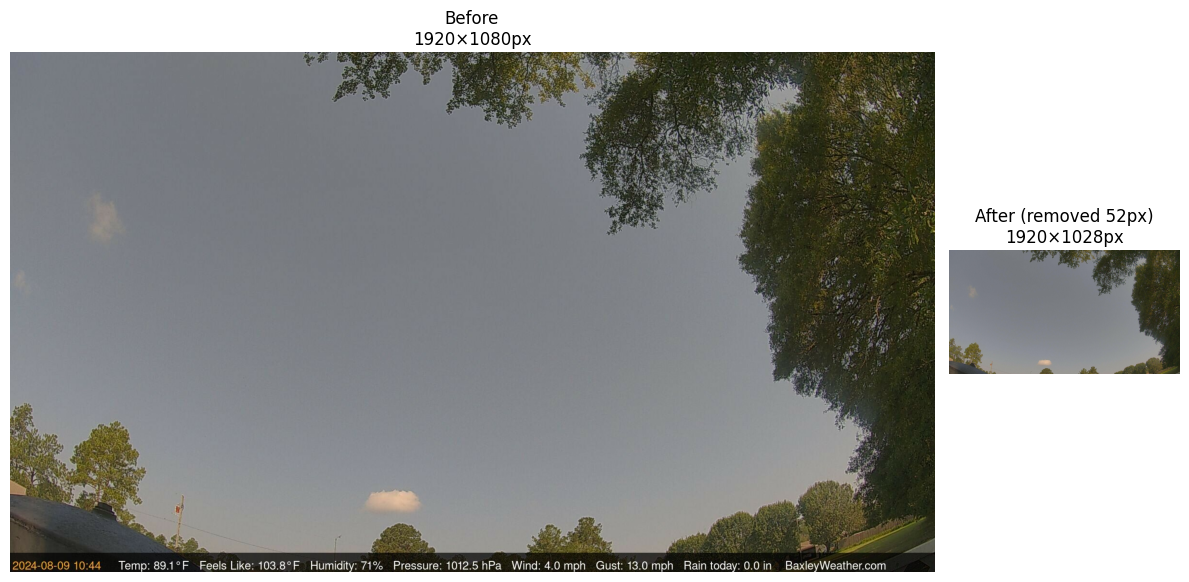

In [19]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

IMG_PATH = Path("../data/7410/snap_7410_20240809_144412_c01d11bc.jpg")

orig_dir = IMG_PATH.parent
clean_dir = orig_dir.parent / f"{orig_dir.name}_clean"
clean_path = clean_dir / IMG_PATH.name

if not IMG_PATH.exists():
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    originals = sorted([p for p in orig_dir.iterdir() if p.suffix.lower() in exts], key=lambda p: p.name)
    assert originals, f"No original images found in {orig_dir}"
    IMG_PATH = originals[0]
    clean_path = clean_dir / IMG_PATH.name

assert clean_path.exists(), f"Matching cleaned image not found: {clean_path}"

with Image.open(IMG_PATH) as im:
    original = im.convert("RGB")
with Image.open(clean_path) as im:
    cropped = im.convert("RGB")

removed_px = original.height - cropped.height

fig, axes = plt.subplots(
    1, 2, figsize=(12, 6),
    gridspec_kw={"width_ratios":[4, 1]}
)
axes[0].imshow(original)
axes[0].set_title(f"Before\n{original.width}×{original.height}px")
axes[0].axis("off")

axes[1].imshow(cropped)
axes[1].set_title(f"After (removed {removed_px}px)\n{cropped.width}×{cropped.height}px")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [20]:
ans = qwen_ask(clean_path, "What is the weather like?")
print(ans)

The weather appears to be clear with a few scattered clouds in the sky.


In [21]:
ans = qwen_ask(clean_path, "What is the temperature?")
print(ans)

The image you provided does not show any temperature readings. To determine the temperature, you would need to look for a weather station or a temperature display on the screen. If you have access to a weather station or a temperature display, you can read the temperature from the image.


In [22]:
ans = qwen_ask(clean_path, "Guess the temperature.")
print(ans)

The temperature in the image is not visible.


In [23]:
ans = qwen_ask(clean_path, "Just take a guess")
print(ans)

The sky appears to be mostly clear with a few scattered clouds. The trees on either side of the frame are lush and green, indicating a healthy environment.


In [24]:
ans = qwen_ask(clean_path, "Take a guess, what the could be the temperature?")
print(ans)

It is difficult to accurately determine the temperature from a single image of the sky. The temperature can vary greatly depending on factors such as the time of day, the season, and the location. However, if you have more information about the time of day, the season, and the location, I can provide a more accurate estimate.


In [25]:
ans = qwen_ask(clean_path, "Look at the image and guess what time it could be.")
print(ans)

The image shows a clear sky with some scattered clouds, and the lighting suggests it is daytime. The lack of shadows and the brightness of the sky indicate that it is likely midday or early afternoon. Therefore, it could be around 12:00 PM to 3:00 PM.


In [26]:
ans = qwen_ask(clean_path, "Look at the image and guess what season it could be.")
print(ans)

The image shows a clear sky with some scattered clouds, and the presence of trees and greenery suggests that it could be spring or summer. The lack of snow or leaves on the trees indicates that it is not winter. Therefore, it is likely that the image was taken in spring or summer.


In [28]:
ans = qwen_ask(clean_path, "So, the season could be spring or summer, and the time is between 12:00PM to 3:00PM, and it is from Baxley, Georgia. Guess the temperature.")
print(ans)

Based on the image, the sky appears clear with a few scattered clouds, and the time is between 12:00PM to 3:00PM. This suggests it is likely spring or summer. The temperature can be estimated by looking at the brightness of the sky and the presence of clouds. 

If the sky is clear and the clouds are few, it could be a sunny day, which is typical for spring or summer. If the sky is mostly cloudy, it could be a cooler day, which is typical for spring. 

Without more specific information, it's difficult to determine the exact temperature. However, if


>I tried, Qwen2-VL-2B-Instruct, not the 7B one, as it was not running properly or taking a lot of time to run on my MacBook Pro M3 Pro.

When I tried, i was unable to run LLaVA, as I was getting many errors and it is always showing messages like "out of memory". And the PaliGemma model was not accessible, it was showing that it is private, and I can't use it.